In [2]:
import torch
import torch.optim as optim
import json
import os
import requests
import sys
import numpy as np

In [3]:
%%writefile models.py
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, context_length):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must divide by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads 
        
        # Combined projection for Q, K, V 
        self.c_attn = nn.Linear(d_model, 3 * d_model, bias=False)
        # Output projection
        self.c_proj = nn.Linear(d_model, d_model, bias=False)
        
        # Lower-triangular causal mask buffer 
        self.register_buffer("bias", torch.tril(torch.ones(context_length, context_length))
                                    .view(1, 1, context_length, context_length))

    def forward(self, x):
        B, T, C = x.size() # Batch, Time (Context), d_model [cite: 18]
        
        # 1. Project to Q, K, V and split heads
        q, k, v = self.c_attn(x).split(self.d_model, dim=2)
        
        # Reshape to (B, n_heads, T, d_k)
        q = q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        
        # 2. Scaled Dot-Product Attention [cite: 20]
        # (B, n_heads, T, d_k) x (B, n_heads, d_k, T) -> (B, n_heads, T, T)
        att = (q @ k.transpose(-2, -1)) * (1.0 / (self.d_k ** 0.5)) 
        
        # Apply causal mask: mask out future positions with -inf
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf')) 
        att = F.softmax(att, dim=-1) 
        
        # 3. Multiply by V and concatenate heads back 
        y = att @ v # (B, n_heads, T, T) x (B, n_heads, T, d_k) -> (B, n_heads, T, d_k)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # Concat heads
        
        return self.c_proj(y)

Writing models.py


In [4]:
%%writefile -a models.py
class PositionWiseFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        # d_ff = 4 * d_model 
        self.w_1 = nn.Linear(d_model, d_ff) 
        self.w_2 = nn.Linear(d_ff, d_model) 
        self.gelu = nn.GELU() 

    def forward(self, x):
        # FFN(x) = GELU(xW1 + b1)W2 + b2 [cite: 24]
        return self.w_2(self.gelu(self.w_1(x)))

Appending to models.py


In [5]:
%%writefile -a models.py
class DecoderBlock(nn.Module):
    def __init__(self, d_model, d_ff, n_heads,max_seq_len):
        super().__init__()
        self.ln_1 = nn.LayerNorm(d_model) 
        self.attn = CausalMultiHeadAttention(d_model, n_heads,max_seq_len)
        self.ln_2 = nn.LayerNorm(d_model) 
        self.ffn = PositionWiseFFN(d_model,d_ff)

    def forward(self, x):
        # x = x + SubLayer(LN(x)) layout 
        x = x + self.attn(self.ln_1(x))
        x = x + self.ffn(self.ln_2(x))
        return x

Appending to models.py


In [6]:
%%writefile -a models.py

class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, d_ff, n_heads, n_layers, max_seq_len):
        super().__init__()
        self. max_seq_len =  max_seq_len
        
        # Foundational Embeddings 
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model) 
        
        # Sequential Transformer Blocks
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, d_ff, n_heads, max_seq_len) for _ in range(n_layers)
        ])
        
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False) 
        
        #  Weight-Tying 
        self.lm_head.weight = self.token_embedding.weight 
        
    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.max_seq_len
        
        # Forward pass through embedding layers
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(pos)
        
        # Pass through Decoder layers
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        
        # Calculate logits 
        logits = self.lm_head(x) # (B, T, vocab_size)
        
        loss = None
        if targets is not None:
            # Flatten tensors for cross-entropy evaluation
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            
        return logits, loss

Appending to models.py


In [7]:
from models import DecoderTransformer
def run_level1_checks():
    print("Starting Level 1 Architecture Verifications\n")
    B, T, d_model, n_heads, n_layers, vocab_size = 2, 8, 64, 2, 2, 65
    
    # Instantiate Model
    model = DecoderTransformer(vocab_size=vocab_size, d_model=d_model, d_ff=256,
                               n_heads=n_heads, n_layers=n_layers,max_seq_len=128)
    model.eval()
    
   
    # 1: Dimension Verification
    
    dummy_input = torch.randint(0, vocab_size, (B, T))
    logits, _ = model(dummy_input)
    assert logits.shape == (B, T, vocab_size), f"Dimension Error! Got shape: {logits.shape}"
    print("1 Passed: Output tensor dimension matched exactly (B, T, V_vocab).\n")
   
    # 2: Causal Compliance Validation
    # Create two sequence tensors where they are identical up to index t=5, but diverge at index t=6 and t=7
    seq_alpha = torch.tensor([[10, 20, 30, 40, 50, 60,  5,  5]], dtype=torch.long)
    seq_beta  = torch.tensor([[10, 20, 30, 40, 50, 60, 64, 64]], dtype=torch.long)
    
    logits_alpha, _ = model(seq_alpha)
    logits_beta, _  = model(seq_beta)
    
    # Outputs for tokens 0 through 5 must remain perfectly mathematically identical
    causal_compliance = torch.allclose(logits_alpha[0, :6, :], logits_beta[0, :6, :], atol=1e-6)
    assert causal_compliance, "Causal Masking Leakage Detected! Future tokens altered past history predictions."
    print(" 2 Passed: Causal compliance verified. Future tokens do not leak into history predictions.\n")
    
  
    # 3: Single-Batch Overfitting Sanity Check
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    
    # Establish a static single chunk data target
    X = torch.randint(0, vocab_size, (B, T))
    Y = torch.randint(0, vocab_size, (B, T))
    
    print("Running Overfitting Optimization (150 iterations)...")
    for step in range(151):
        logits, loss = model(X, Y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if step % 50 == 0:
            print(f"  Iteration {step:3d} | Batch Cross-Entropy Loss: {loss.item():.4f}")
            
    assert loss.item() < 0.05, f"Overfitting failed. Architecture contains math bugs. Loss: {loss.item()}"
    print("\n 3 Passed: Mathematical completeness verified. Loss crushed to ~0.")
    print("\n Level 1 Implementation Completely Validated!")

if __name__ == "__main__":
    run_level1_checks()

Starting Level 1 Architecture Verifications

1 Passed: Output tensor dimension matched exactly (B, T, V_vocab).

 2 Passed: Causal compliance verified. Future tokens do not leak into history predictions.

Running Overfitting Optimization (150 iterations)...
  Iteration   0 | Batch Cross-Entropy Loss: 41.3646
  Iteration  50 | Batch Cross-Entropy Loss: 0.0012
  Iteration 100 | Batch Cross-Entropy Loss: 0.0005
  Iteration 150 | Batch Cross-Entropy Loss: 0.0003

 3 Passed: Mathematical completeness verified. Loss crushed to ~0.

 Level 1 Implementation Completely Validated!


In [8]:
%%writefile train_scaling.py

import os
import json
import requests
import torch
import torch.optim as optim
from models import DecoderTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Executing natively inside notebook cell using device: {device}", flush=True)

# 1. Dataset Downloading & Preprocessing Pipeline
def load_dataset():
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    filename = "input.txt"
    
    if not os.path.exists(filename) or os.path.getsize(filename) == 0:
        print("Downloading Tiny Shakespeare corpus...", flush=True)
        response = requests.get(url)
        response.raise_for_status()
        with open(filename, "w", encoding="utf-8") as f:
            f.write(response.text)
            
    with open(filename, "r", encoding="utf-8") as f:
        text = f.read()
        
    chars = sorted(list(set(text)))
    vocab_size = len(chars)
    
    char2int = {ch: i for i, ch in enumerate(chars)}
    data = torch.tensor([char2int[c] for c in text], dtype=torch.long)
    
    n = int(0.9 * len(data))
    train_data = data[:n]
    val_data = data[n:]
    
    return train_data, val_data, vocab_size

train_data, val_data, vocab_size = load_dataset()
print(f"Dataset prepared. Vocab Size: {vocab_size} | Train tokens: {len(train_data)}", flush=True)

# 2. Continuous Chunk Batching Pipeline
def get_batch(split, batch_size, context_length, data_fraction=1.0):
    if split == 'train':
        limit = int(len(train_data) * data_fraction)
        data_source = train_data[:limit]
    else:
        data_source = val_data
        
    ix = torch.randint(len(data_source) - context_length, (batch_size,))
    x = torch.stack([data_source[i : i + context_length] for i in ix])
    y = torch.stack([data_source[i + 1 : i + context_length + 1] for i in ix])
    
    return x.to(device), y.to(device)

def count_non_embedding_params(model):
    return sum(p.numel() for name, p in model.named_parameters()
               if 'embed' not in name and 'lm_head' not in name)

# 3. Standardized Core Training Execution Wrapper
def train_model(config, data_fraction=1.0, max_steps=3000, batch_size=32):
    model = DecoderTransformer(
        vocab_size=vocab_size,
        d_model=config['d_model'],
        d_ff=config['d_ff'],   
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        max_seq_len=config['max_seq_len']
    ).to(device)
    
    N = count_non_embedding_params(model)
    print(f"\n[INIT] Scale: {config['name']} | Non-Embed Params (N): {N}", flush=True)
    
    optimizer = optim.AdamW(model.parameters(), lr=6e-4, weight_decay=0.1)
    best_val_loss = float('inf')
    model.train()
    
    for step in range(1, max_steps + 1):
        x_batch, y_batch = get_batch('train', batch_size, config['max_seq_len'], data_fraction)
        logits, loss = model(x_batch, y_batch)
        
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        if step % 500 == 0:
            print(f"    Step {step:4d}/{max_steps} | Batch Train Loss: {loss.item():.4f}", flush=True)
            
        if step % 1000 == 0 or step == max_steps:
            model.eval()
            val_loss_accum = 0.0
            val_steps = 20
            with torch.no_grad():
                for _ in range(val_steps):
                    x_v, y_v = get_batch('val', batch_size, config['max_seq_len'])
                    _, v_loss = model(x_v, y_v)
                    val_loss_accum += v_loss.item()
                    
            current_val_loss = val_loss_accum / val_steps
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
            print(f" >> [EVAL] Step {step} | Current Best Val Loss: {best_val_loss:.4f}", flush=True)
            model.train()
                
    D = max_steps * batch_size * config['max_seq_len'] * data_fraction
    return N, D, best_val_loss

# 4. Main Sweeps Coordinator Loop
if __name__ == "__main__":
    model_profiles = {
        "Tiny":   {"name": "Tiny",   "n_layers": 2, "d_model": 64,  "d_ff": 256,  "max_seq_len": 128, "n_heads": 2},
        "Small":  {"name": "Small",  "n_layers": 4, "d_model": 128, "d_ff": 512,  "max_seq_len": 256, "n_heads": 4},
        "Medium": {"name": "Medium", "n_layers": 6, "d_model": 256, "d_ff": 1024, "max_seq_len": 256, "n_heads": 8}
    }

    results = {
        "parameter_sweep": [],
        "data_sweep": []
    }

    print("\n=== STARTING SWEEP 1: PARAMETER SCALING ===", flush=True)
    for scale_name in ["Tiny", "Small", "Medium"]:
        config = model_profiles[scale_name]
        N, _, best_loss = train_model(config, data_fraction=1.0)
        results["parameter_sweep"].append({"name": scale_name, "N": N, "loss": best_loss})
        
    print("\n=== STARTING SWEEP 2: DATA SCALING ===", flush=True)
    small_config = model_profiles["Small"]
    data_fractions = [0.10, 0.25, 0.50, 1.00]

    for fraction in data_fractions:
        if fraction == 1.00 and len(results["parameter_sweep"]) >= 2:
            small_run = results["parameter_sweep"][1]
            N = small_run["N"]
            D = 3000 * 32 * small_config['max_seq_len'] * 1.0
            best_loss = small_run["loss"]
            print(f"\n[CACHE] Using cached Small model metrics for {fraction*100}% data.", flush=True)
        else:
            N, D, best_loss = train_model(small_config, data_fraction=fraction)
            
        results["data_sweep"].append({"fraction": fraction, "D": D, "loss": best_loss})

    with open("sweep_results.json", "w") as f:
        json.dump(results, f, indent=4)
        
    print("\n Sweeps Complete! Saved to sweep_results.json", flush=True)

Writing train_scaling.py


In [9]:
%run train_scaling.py

Executing natively inside notebook cell using device: cuda
Dataset prepared. Vocab Size: 65 | Train tokens: 1003854

=== STARTING SWEEP 1: PARAMETER SCALING ===

[INIT] Scale: Tiny | Non-Embed Params (N): 99584
    Step  500/3000 | Batch Train Loss: 2.5700
    Step 1000/3000 | Batch Train Loss: 2.4801
 >> [EVAL] Step 1000 | Current Best Val Loss: 2.5095
    Step 1500/3000 | Batch Train Loss: 2.3546
    Step 2000/3000 | Batch Train Loss: 2.2114
 >> [EVAL] Step 2000 | Current Best Val Loss: 2.2567
    Step 2500/3000 | Batch Train Loss: 2.0508
    Step 3000/3000 | Batch Train Loss: 2.0126
 >> [EVAL] Step 3000 | Current Best Val Loss: 2.0805

[INIT] Scale: Small | Non-Embed Params (N): 791296
    Step  500/3000 | Batch Train Loss: 2.4847
    Step 1000/3000 | Batch Train Loss: 2.3832
 >> [EVAL] Step 1000 | Current Best Val Loss: 2.4202
    Step 1500/3000 | Batch Train Loss: 2.1817
    Step 2000/3000 | Batch Train Loss: 2.0236
 >> [EVAL] Step 2000 | Current Best Val Loss: 2.1067
    Step 250

In [14]:
%%writefile plot_scaling.py
import json
import numpy as np
import matplotlib.pyplot as plt

def fit_and_plot_laws():
    # 1. Load the generated sweep results
    try:
        with open("sweep_results.json", "r") as f:
            results = json.load(f)
    except FileNotFoundError:
        print("Error: sweep_results.json not found! Please wait for train_scaling.py to finish running completely.")
        return

    # Extract Parameter Sweep Data
    param_data = results["parameter_sweep"]
    names = [d["name"] for d in param_data]
    N_vals = np.array([d["N"] for d in param_data], dtype=float)
    L_N_vals = np.array([d["loss"] for d in param_data], dtype=float)

    # Extract Data Sweep Data
    data_sweep = results["data_sweep"]
    D_vals = np.array([d["D"] for d in data_sweep], dtype=float)
    L_D_vals = np.array([d["loss"] for d in data_sweep], dtype=float)

    # 2. Fit power laws in log-log space using numpy.polyfit
    # log(L(N)) = constant - alpha_N * log(N) -> slope is -alpha_N
    slope_N, intercept_N = np.polyfit(np.log10(N_vals), np.log10(L_N_vals), 1)
    alpha_N = -slope_N

    # log(L(D)) = constant - alpha_D * log(D) -> slope is -alpha_D
    slope_D, intercept_D = np.polyfit(np.log10(D_vals), np.log10(L_D_vals), 1)
    alpha_D = -slope_D

    # Calculate scaling ratio gamma
    gamma = alpha_N / alpha_D

    print("EMPIRICAL SCALING LAW RESULTS")
    print(f"Calculated alpha_N (Parameter exponent): {alpha_N:.4f}")
    print(f"Calculated alpha_D (Data exponent):      {alpha_D:.4f}")
    print(f"Calculated Scaling Ratio (gamma):        {gamma:.4f}")

    # 3. Generate Dual Log-Log Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left Plot: Parameter Scaling
    ax1.scatter(N_vals, L_N_vals, color='red', s=100, zorder=5, label='Empirical Models')
    for i, txt in enumerate(names):
        ax1.annotate(f" {txt}", (N_vals[i], L_N_vals[i]), fontsize=11, weight='bold')
    
    # Fit line projection
    N_fit_line = np.linspace(min(N_vals)*0.5, max(N_vals)*2, 100)
    L_N_fit_line = 10**(intercept_N) * (N_fit_line**slope_N)
    ax1.plot(N_fit_line, L_N_fit_line, 'k--', alpha=0.7, label=f'Fit Line ($\\alpha_N$ = {alpha_N:.3f})')
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Non-Embedding Parameters ($N$)', fontsize=12)
    ax1.set_ylabel('Minimal Validation Cross-Entropy Loss ($L$)', fontsize=12)
    ax1.set_title('Parameter Scaling Law Fit', fontsize=13, weight='bold')
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    ax1.legend(fontsize=10)

    # Right Plot: Data Scaling
    ax2.scatter(D_vals, L_D_vals, color='blue', s=100, zorder=5, label='Data Budgets')
    fractions = ["10%", "25%", "50%", "100%"]
    for i, txt in enumerate(fractions):
        ax2.annotate(f" {txt}", (D_vals[i], L_D_vals[i]), fontsize=11, weight='bold')
        
    # Fit line projection
    D_fit_line = np.linspace(min(D_vals)*0.5, max(D_vals)*2, 100)
    L_D_fit_line = 10**(intercept_D) * (D_fit_line**slope_D)
    ax2.plot(D_fit_line, L_D_fit_line, 'k--', alpha=0.7, label=f'Fit Line ($\\alpha_D$ = {alpha_D:.3f})')
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Dataset Size in Total Tokens ($D$)', fontsize=12)
    ax2.set_ylabel('Minimal Validation Cross-Entropy Loss ($L$)', fontsize=12)
    ax2.set_title('Data Scaling Law Fit', fontsize=13, weight='bold')
    ax2.grid(True, which="both", ls="-", alpha=0.2)
    ax2.legend(fontsize=10)

    plt.suptitle(f"Neural Language Model Power-Law Scaling Metrics ($\\gamma$ = {gamma:.3f})", fontsize=15, weight='bold', y=1.02)
    plt.tight_layout()
    
    # Save chart asset cleanly to environment workspace
    plt.savefig("scaling_laws.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Success! High-resolution scaling curves exported to 'scaling_laws.png'")

if __name__ == "__main__":
    fit_and_plot_laws()

Overwriting plot_scaling.py


EMPIRICAL SCALING LAW RESULTS
Calculated alpha_N (Parameter exponent): 0.0564
Calculated alpha_D (Data exponent):      0.1516
Calculated Scaling Ratio (gamma):        0.3720


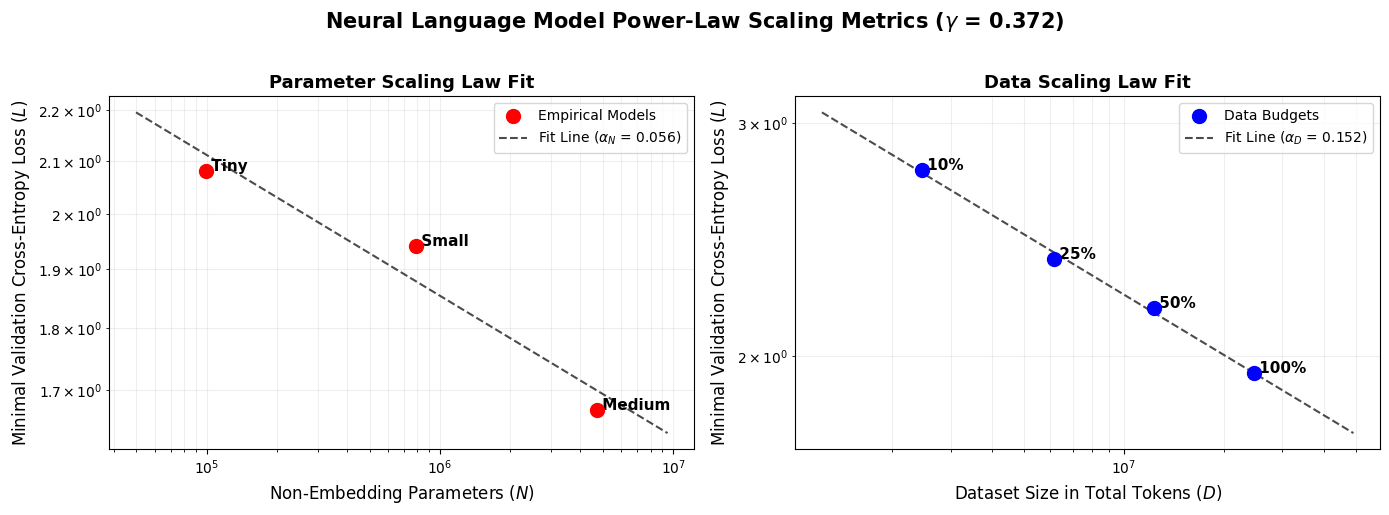

Success! High-resolution scaling curves exported to 'scaling_laws.png'


<Figure size 640x480 with 0 Axes>

In [15]:
%run plot_scaling.py